C:\Users\DELL\AppData\Local\Temp\ipykernel_6436\341905835.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_counts, x="Số lượng", y="Loại thực thể (BIO)", palette="viridis")


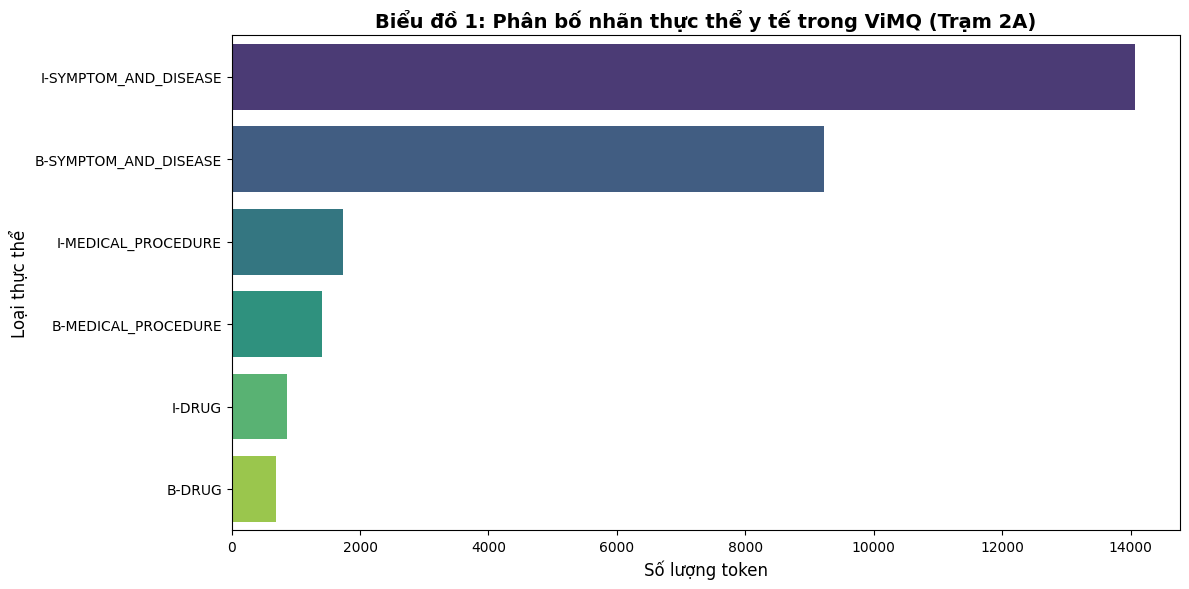

✅ Đã lưu: reports/figures/ner_label_distribution.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu NER thực tế từ file conll
ner_tags = []
with open("D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/data/ner_train.conll", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith("-DOCSTART-"):
            parts = line.split()
            if len(parts) >= 2:
                tag = parts[-1]
                # Bỏ qua nhãn O để focus vào các thực thể bệnh/thuốc
                if tag not in ["O", "IGN"]: 
                    ner_tags.append(tag)

df_ner = pd.DataFrame(ner_tags, columns=["Tag"])
tag_counts = df_ner["Tag"].value_counts().reset_index()
tag_counts.columns = ["Loại thực thể (BIO)", "Số lượng"]

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(data=tag_counts, x="Số lượng", y="Loại thực thể (BIO)", palette="viridis")
plt.title("Biểu đồ 1: Phân bố nhãn thực thể y tế trong ViMQ (Trạm 2A)", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng token", fontsize=12)
plt.ylabel("Loại thực thể", fontsize=12)
plt.tight_layout()

# 3. Lưu ảnh
plt.savefig("D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/reports/figures/ner_label_distribution.png", dpi=300)
plt.show()
print("✅ Đã lưu: reports/figures/ner_label_distribution.png")

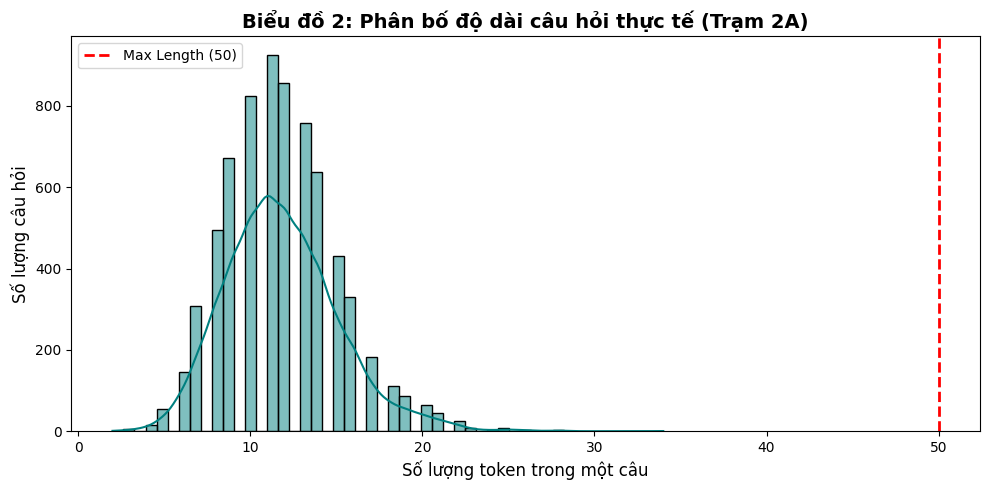

✅ Đã lưu: reports/figures/ner_sequence_length.png


In [10]:
# 1. Tính toán độ dài từng câu trong tập train
sentence_lengths = []
current_len = 0
with open("D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/data/ner_train.conll", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("-DOCSTART-"):
            if current_len > 0:
                sentence_lengths.append(current_len)
                current_len = 0
        else:
            current_len += 1
if current_len > 0:
    sentence_lengths.append(current_len)

# 2. Vẽ Histogram
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=50, kde=True, color="teal")
plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Max Length (50)')
plt.title("Biểu đồ 2: Phân bố độ dài câu hỏi thực tế (Trạm 2A)", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng token trong một câu", fontsize=12)
plt.ylabel("Số lượng câu hỏi", fontsize=12)
plt.legend()
plt.tight_layout()

# 3. Lưu ảnh
plt.savefig("D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/reports/figures/ner_sequence_length.png", dpi=300)
plt.show()
print("✅ Đã lưu: reports/figures/ner_sequence_length.png")